# Seminar 01 — Robot Learning Data & Action Spaces

**student** · Python / CPU

We inspect how observations, states and actions are represented before training a policy:
$\pi:(o_t,s_t,\ell)\mapsto a_{t:t+H-1}$.
By the end you will audit episodes, interpret RGB and vectors, construct action targets,
find a temporal alignment error, and compare absolute and delta representations.

Complete the laboratory work independently. Run the notebook from top to bottom and replace
every `TO DO` and `NotImplementedError` with your own code. After each experiment, answer all
questions in the corresponding **Your task** cell using the values, tables and plots produced by
your run. Keep your code, written answers and cell outputs in the notebook. When all checks pass,
save the completed notebook and send the `.ipynb` file to the instructor.

The local dataset contains synthetic SO-ARM100 demonstrations: 4 episodes with 100 frames each,
recorded at 10 Hz. Each frame contains a front RGB image, robot state and language instruction.
Cube attachment is scripted, so these kinematic examples do not prove physical grasp success.
No simulator or network connection is needed to complete the laboratory work.

## LeRobotDataset v3.0
LeRobotDataset v3.0 stores synchronized robot observations and actions as frames grouped into
episodes. Vector data and metadata use Parquet; cameras can use video, while this small dataset
keeps lossless images in Parquet. `meta/info.json` declares the format version, FPS, feature
shapes and paths; separate metadata files describe episodes, tasks and feature statistics.

Here `observation.state` contains five joint angles, EE XYZ and the jaw angle. `action` contains
the next-frame absolute joint and jaw target. `action_valid=False` marks the padded final frame
of every episode and must mask the loss. LeRobot supplies indices and timestamps and returns the
instruction as `task`. The local dataset was created with `create`, `add_frame`, `save_episode`
and the required final `finalize` call. Every converted frame was checked against the source data.
See the
[official format documentation](https://huggingface.co/docs/lerobot/v0.4.3/en/lerobot-dataset-v3).

## A. Setup and dataset structure
Run the setup first. A frame contains synchronized observations; a transition also needs a
valid successor in the **same episode**. A reset is not a robot action.
We load the converted LeRobotDataset v3.0 from local storage.
Real recording streams require decoding, synchronization and a precise action definition first.

In [1]:
from pathlib import Path
import json
import platform
import warnings
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'font.size': 10})
warnings.filterwarnings('ignore', message='IProgress not found.*')
import torch
from lerobot.datasets.lerobot_dataset import LeRobotDataset
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Python {platform.python_version()} | device={device}')
print({p: metadata.version(p) for p in ['numpy', 'pandas', 'matplotlib', 'Pillow', 'lerobot', 'torch']})

# Works from this folder, the seminar folder, or the repository root.
DATA_DIR = None  # Alternatively set Path('/content/.../notebooks/data/lerobot_v3').
if DATA_DIR is None:
    candidates = [Path.cwd(), *Path.cwd().parents]
    DATA_DIR = next((base / rel for base in candidates
                     for rel in ['data/lerobot_v3', 'notebooks/data/lerobot_v3',
                                 '01-robotic-learning-data/notebooks/data/lerobot_v3']
                     if (base / rel / 'meta/info.json').is_file()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Keep notebooks/data/lerobot_v3 beside the notebook; see README.md.')
lerobot_dataset = LeRobotDataset('local/seminar-01-soarm100', root=DATA_DIR)
assert lerobot_dataset.meta.info['codebase_version'] == 'v3.0'
print(lerobot_dataset)
# This teaching dataset is small enough to materialize. Training code normally reads lazily.
# Keep familiar NumPy names for the exercises; stored action targets remain hidden.
samples = [lerobot_dataset[row] for row in range(len(lerobot_dataset))]
stored_state = np.stack([sample['observation.state'].numpy() for sample in samples])
data = {
    'front_rgb': np.stack([sample['observation.images.front'].permute(1, 2, 0)
                          .mul(255).round().byte().numpy() for sample in samples]),
    'joint_pos': stored_state[:, :5], 'ee_xyz': stored_state[:, 5:8],
    'gripper': stored_state[:, 8:9],
    'timestamp': np.array([sample['timestamp'].item() for sample in samples]),
    'instruction': np.array([sample['task'] for sample in samples]),
    'episode_id': np.array([sample['episode_index'].item() for sample in samples]),
    'frame_index': np.array([sample['frame_index'].item() for sample in samples]),
}
del samples, stored_state
x = data['ee_xyz'].astype(np.float64)
episode_id = data['episode_id']
print('Loaded LeRobotDataset v3.0 | frames:', len(x))

Python 3.12.3 | device=cuda
{'numpy': '2.2.6', 'pandas': '3.0.5', 'matplotlib': '3.11.1', 'Pillow': '12.3.0', 'lerobot': '0.4.3', 'torch': '2.7.1'}
LeRobotDataset({
    Repository ID: 'local/seminar-01-soarm100',
    Number of selected episodes: '4',
    Number of selected samples: '400',
    Features: '['observation.images.front', 'observation.state', 'action', 'action_valid', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})',

Loaded LeRobotDataset v3.0 | frames: 400


In [2]:
units = {'front_rgb': 'RGB intensity [0,255]', 'joint_pos': 'rad; five arm joints',
         'ee_xyz': 'm; world frame, table z=0', 'gripper': 'rad; jaw angle',
         'timestamp': 's; episode-local', 'instruction': 'text',
         'episode_id': 'episode identity', 'frame_index': 'episode-local index'}
display(pd.DataFrame([{'field': k, 'shape': str(v.shape), 'dtype': str(v.dtype),
                       'meaning / units': units[k]} for k, v in data.items()]))

checks = []
def check(name, condition, details):
    checks.append({'check': name, 'status': 'PASS' if condition else 'FAIL', 'details': details})

n = len(x)
check('Aligned lengths', all(len(v) == n for v in data.values()), f'{n} frames')
check('RGB schema', data['front_rgb'].shape == (n, 240, 320, 3)
      and data['front_rgb'].dtype == np.uint8, 'NHWC uint8; RGB')
for key, width in [('joint_pos', 5), ('ee_xyz', 3), ('gripper', 1)]:
    check(key, data[key].shape == (n, width) and data[key].dtype == np.float32
          and np.isfinite(data[key]).all(), f'float32, finite, width={width}')
check('Integer indices', all(np.issubdtype(data[k].dtype, np.integer)
      for k in ['episode_id', 'frame_index']), 'episode and frame indices')
for ep in np.unique(episode_id):
    idx = np.flatnonzero(episode_id == ep)
    dt = np.diff(data['timestamp'][idx])
    check(f'Episode {ep}', np.all(np.diff(idx) == 1)
          and np.array_equal(data['frame_index'][idx], np.arange(len(idx)))
          and np.isfinite(data['timestamp'][idx]).all() and np.all(dt > 0)
          and np.allclose(dt, 0.1)
          and len(np.unique(data['instruction'][idx])) == 1
          and bool(str(data['instruction'][idx[0]]).strip()),
          f'{len(idx)} ordered frames; finite timestamps, 10 Hz; one instruction')
audit_table = pd.DataFrame(checks)
display(audit_table.style.map(lambda v: 'color: green' if v == 'PASS' else 'color: red', subset=['status']))
assert (audit_table.status == 'PASS').all(), 'Fix the dataset validation error before continuing.'

,field,shape,dtype,meaning / units
0,front_rgb,"(400, 240, 320, 3)",uint8,"RGB intensity [0,255]"
1,joint_pos,"(400, 5)",float32,rad; five arm joints
2,ee_xyz,"(400, 3)",float32,"m; world frame, table z=0"
3,gripper,"(400, 1)",float32,rad; jaw angle
4,timestamp,"(400,)",float64,s; episode-local
5,instruction,"(400,)",<U29,text
6,episode_id,"(400,)",int64,episode identity
7,frame_index,"(400,)",int64,episode-local index


,check,status,details
0,Aligned lengths,PASS,400 frames
1,RGB schema,PASS,NHWC uint8; RGB
2,joint_pos,PASS,"float32, finite, width=5"
3,ee_xyz,PASS,"float32, finite, width=3"
4,gripper,PASS,"float32, finite, width=1"
5,Integer indices,PASS,episode and frame indices
6,Episode 0,PASS,"100 ordered frames; finite timestamps, 10 Hz; one instruction"
7,Episode 1,PASS,"100 ordered frames; finite timestamps, 10 Hz; one instruction"
8,Episode 2,PASS,"100 ordered frames; finite timestamps, 10 Hz; one instruction"
9,Episode 3,PASS,"100 ordered frames; finite timestamps, 10 Hz; one instruction"


## B. Anatomy of an episode
`front_rgb[t]` is the visual observation $o_t$. The state vector $s_t$ contains five joint
angles, three Cartesian coordinates and one jaw angle: **9 values with mixed units**.
The instruction is constant within an episode. An action is a future target, not another
name for the measured state. We do not concatenate RGB pixels and meters into one raw vector.

The gripper is an angle: approximately 0.70 rad means open and 0.05 rad means closed.
It is not a binary success label. EE XYZ omits orientation; a real controller needs a more complete observation and action specification.

,episode,frames,instruction
0,0,100,place the red cube in the bin
1,1,100,place the red cube in the bin
2,2,100,place the red cube in the bin
3,3,100,place the red cube in the bin


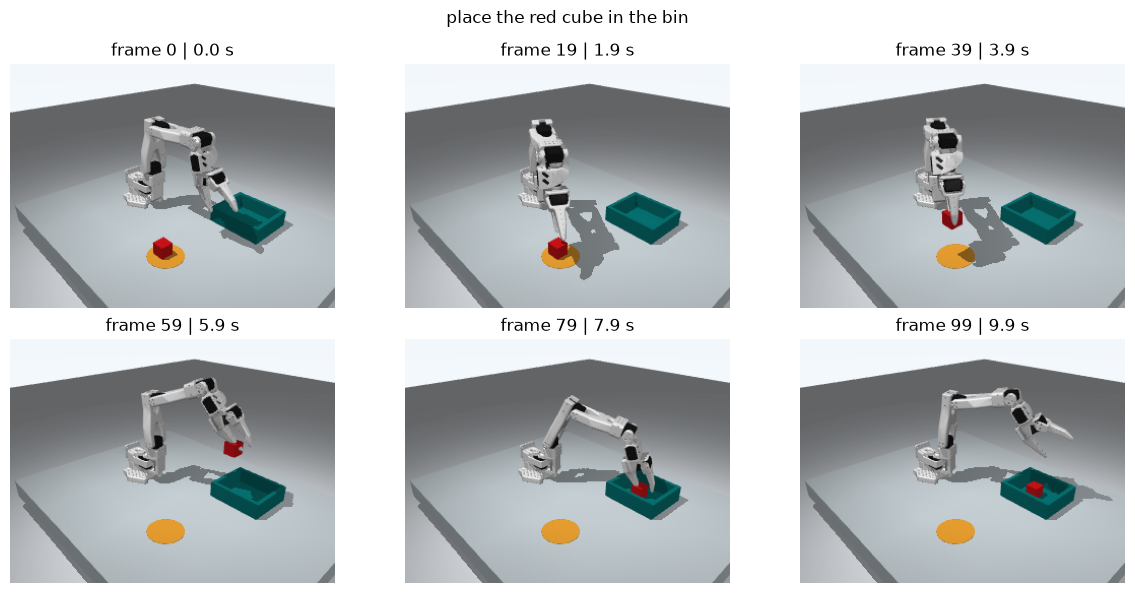

In [3]:
summary = []
for ep in np.unique(episode_id):
    idx = np.flatnonzero(episode_id == ep)
    summary.append({'episode': ep, 'frames': len(idx),
                    'instruction': data['instruction'][idx[0]]})
display(pd.DataFrame(summary))
EPISODE = 0  # Change to 0, 1, 2, or 3.
ep_idx = np.flatnonzero(episode_id == EPISODE)
assert len(ep_idx), 'Unknown episode'
strip_idx = ep_idx[np.linspace(0, len(ep_idx) - 1, 6, dtype=int)]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, i in zip(axes.flat, strip_idx):
    ax.imshow(data['front_rgb'][i]); ax.axis('off')
    ax.set_title(f'frame {data["frame_index"][i]} | {data["timestamp"][i]:.1f} s')
fig.suptitle(str(data['instruction'][ep_idx[0]])); plt.tight_layout(); plt.show()

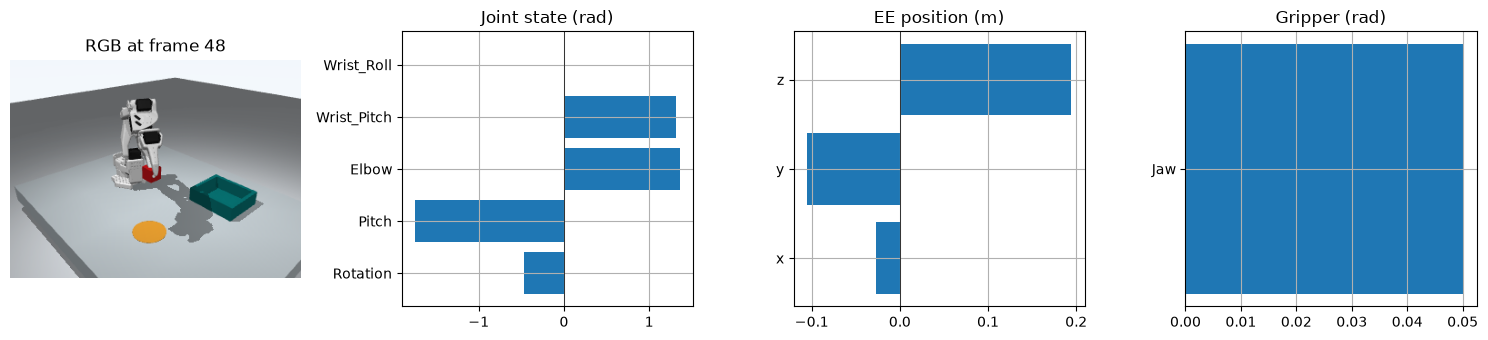

state shape: (400, 9) | state[t]: [-0.4687 -1.7466  1.3575  1.3163  0.     -0.0266 -0.1054  0.1946  0.05  ]
language: place the red cube in the bin


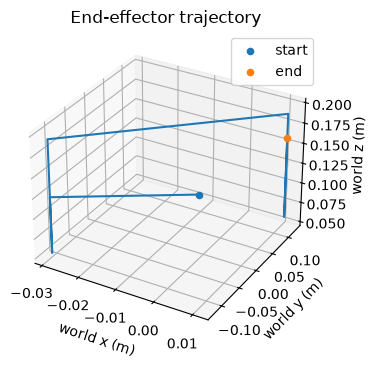

In [4]:
# One concrete multimodal sample: RGB + named vector components + language.
i = ep_idx[48]
joint_names = ['Rotation', 'Pitch', 'Elbow', 'Wrist_Pitch', 'Wrist_Roll']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
axes[0].imshow(data['front_rgb'][i]); axes[0].axis('off'); axes[0].set_title(f'RGB at frame {data["frame_index"][i]}')
for ax, values, names, title in zip(axes[1:],
    [data['joint_pos'][i], x[i], data['gripper'][i]],
    [joint_names, ['x', 'y', 'z'], ['Jaw']], ['Joint state (rad)', 'EE position (m)', 'Gripper (rad)']):
    ax.barh(names, values); ax.set_title(title); ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()
state = np.concatenate([data['joint_pos'], x, data['gripper']], axis=1)
print('state shape:', state.shape, '| state[t]:', np.round(state[i], 4))
print('language:', data['instruction'][i])
fig = plt.figure(figsize=(6, 4)); ax = fig.add_subplot(projection='3d')
ax.plot(*x[ep_idx].T); ax.scatter(*x[ep_idx[0]], label='start'); ax.scatter(*x[ep_idx[-1]], label='end')
ax.set(xlabel='world x (m)', ylabel='world y (m)', zlabel='world z (m)', title='End-effector trajectory')
ax.legend(); plt.show()

**Your task.** Describe the multimodal sample above in two short sentences:

1. List the three parts of `state[t]` and their dimensions.
- 5 joint angles -> 5 dimentions
- end-effector position (XYZ coordinate) -> 3 dimentions
- gripper angle -> 1 dimention

2. Name one piece of information that cannot be recovered from a single RGB frame.<br>
Depth/distances

## C. Plot modalities and timing
Signals must share the same time axis. A timestamp reset at an episode boundary is expected;
a duplicate or decreasing timestamp **within** an episode is a problem. At 10 Hz, one step
lasts 0.1 s. A delta in meters per step is not a velocity in meters per second.

### C1. Select synchronized vectors

Return `(time, joints, ee, gripper)` for `indices`, with shapes `(T,), (T,5), (T,3), (T,1)`. The plotting boilerplate is supplied.

<details><summary>Hint 1</summary>

Use the same index array for every field.

</details>

<details><summary>Hint 2</summary>

Read timestamp, joint_pos, ee_xyz and gripper in that order, then select indices.

</details>

In [5]:
def select_signals(dataset, indices):
    # TO DO: select the same rows in all four modalities.
    time    = dataset['timestamp'][indices]
    joints  = dataset['joint_pos'][indices]
    ee      = dataset['ee_xyz'][indices]
    gripper = dataset['gripper'][indices]
    return time, joints, ee, gripper

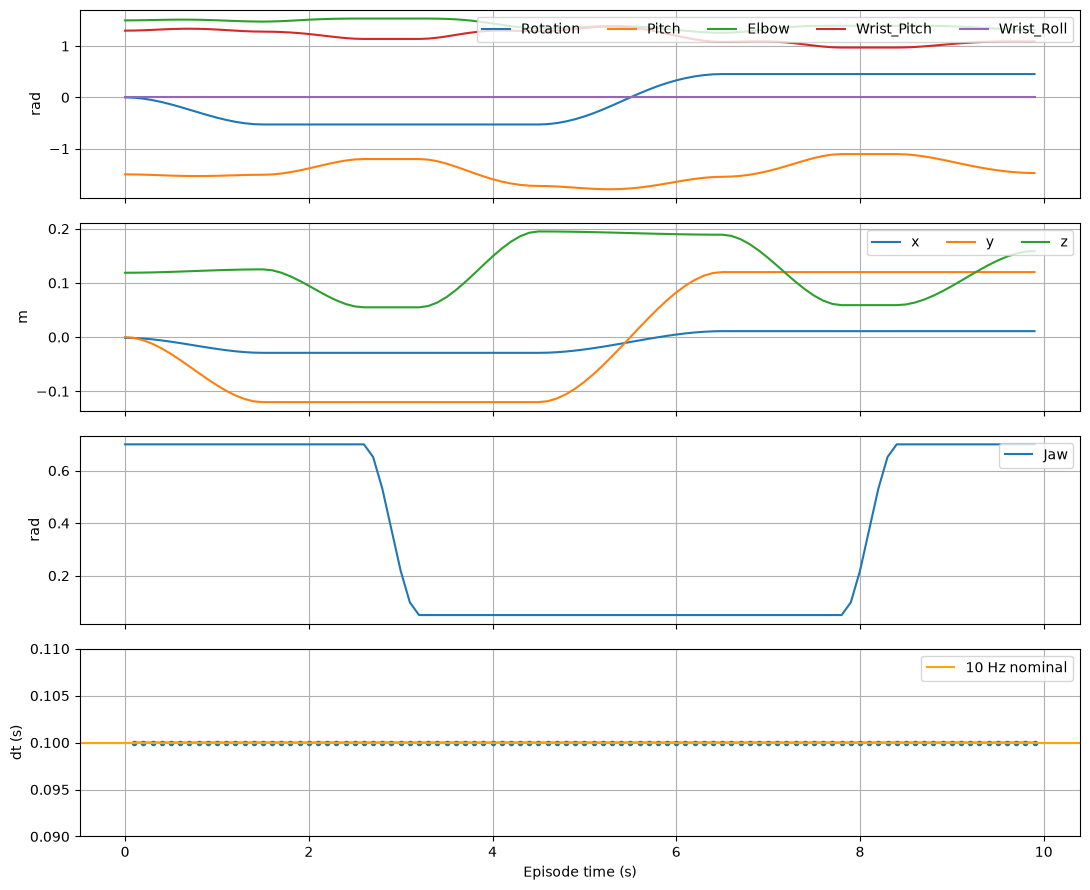

dt min/max: 0.099999/0.100000 s; duplicates: 0


,channel,std
0,Rotation,4.391971e-01
1,Pitch,2.072785e-01
2,Elbow,8.345156e-02
3,Wrist_Pitch,1.267400e-01
4,Wrist_Roll,2.091077e-17
5,x,1.779892e-02
6,y,1.071260e-01
7,z,4.956897e-02
8,Jaw,3.145454e-01


In [6]:
time, joints, ee, grip = select_signals(data, ep_idx)
assert [v.shape for v in (time, joints, ee, grip)] == [(len(ep_idx),), (len(ep_idx), 5), (len(ep_idx), 3), (len(ep_idx), 1)]
np.testing.assert_array_equal(ee, data['ee_xyz'][ep_idx])
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
for ax, values, labels, unit in [(axes[0], joints, joint_names, 'rad'),
    (axes[1], ee, ['x', 'y', 'z'], 'm'), (axes[2], grip, ['Jaw'], 'rad')]:
    ax.plot(time, values); ax.set_ylabel(unit); ax.legend(labels, loc='upper right', ncol=len(labels))
dt = np.diff(time)
axes[3].plot(time[1:], dt, '.-'); axes[3].axhline(0.1, color='orange', label='10 Hz nominal')
axes[3].set(xlabel='Episode time (s)', ylabel='dt (s)', ylim=(0.09, 0.11)); axes[3].legend()
plt.tight_layout(); plt.show()
print(f'dt min/max: {dt.min():.6f}/{dt.max():.6f} s; duplicates: {(dt == 0).sum()}')
display(pd.DataFrame({'channel': joint_names + ['x', 'y', 'z', 'Jaw'], 'std': state[ep_idx].std(axis=0)}))

### Locate events from synchronized evidence
Use the jaw signal to find the frame ranges where the gripper moves. Then inspect the
corresponding RGB frames. In this recording, decreasing jaw angle corresponds to grasping the
cube, and increasing jaw angle corresponds to releasing it.

Frame transitions where the jaw angle changes: [(26, 27), (27, 28), (28, 29), (29, 30), (30, 31), (31, 32), (78, 79), (79, 80), (80, 81), (81, 82), (82, 83), (83, 84)]


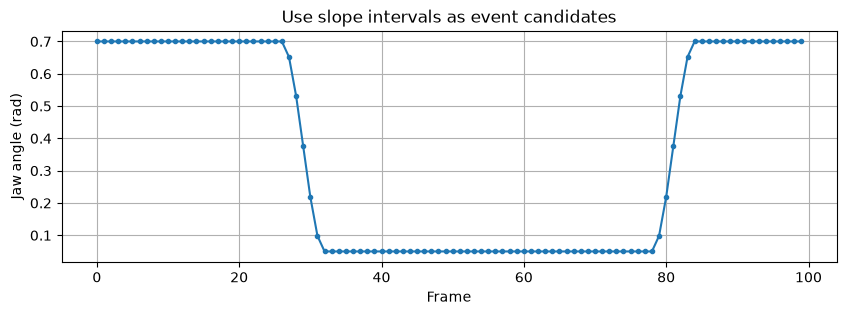

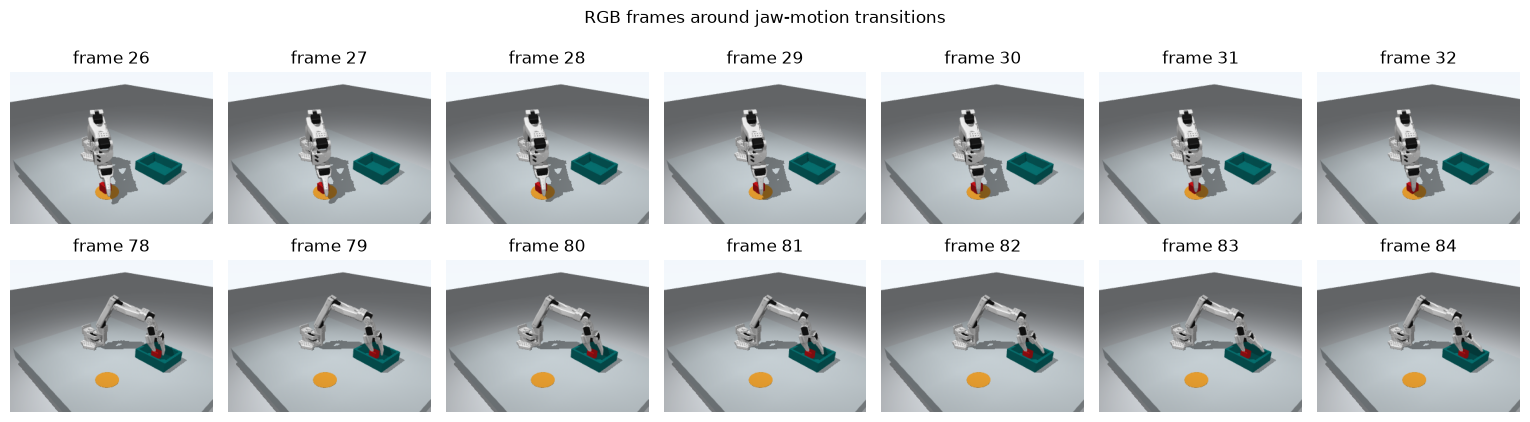

In [7]:
episode_frames = data['frame_index'][ep_idx]
episode_jaw = data['gripper'][ep_idx, 0]
change_edges = np.flatnonzero(np.abs(np.diff(episode_jaw)) > 1e-6)
change_intervals = [(int(episode_frames[j]), int(episode_frames[j + 1])) for j in change_edges]
print('Frame transitions where the jaw angle changes:', change_intervals)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(episode_frames, episode_jaw, '.-')
ax.set(xlabel='Frame', ylabel='Jaw angle (rad)', title='Use slope intervals as event candidates')
plt.show()

candidate_local = np.unique(np.r_[change_edges, change_edges + 1])
candidate_rows = ep_idx[candidate_local]
ncols = int(np.ceil(len(candidate_rows) / 2))
fig, axes = plt.subplots(2, ncols, figsize=(2.2 * ncols, 4.5))
for ax, row in zip(axes.flat, candidate_rows):
    ax.imshow(data['front_rgb'][row]); ax.axis('off')
    ax.set_title(f'frame {data["frame_index"][row]}')
for ax in axes.flat[len(candidate_rows):]:
    ax.axis('off')
fig.suptitle('RGB frames around jaw-motion transitions')
plt.tight_layout(); plt.show()

**Your task.** Use the printed values, the standard-deviation table,
the jaw-angle graph and the RGB frames above. Write four answers:

1. What is the step between consecutive records in the dataset, in seconds?<br>
0.1 s (10 Hz)

2. Are there duplicate timestamps inside the episode? Give their count.<br>
No, count: 0.

3. Which channel does not change? Write its exact name from the table.<br>
Wrist_Roll

4. At which frame range does the jaw close to grasp the cube, and at which frame range does it
   open to release the cube?<br>
Close: frames 26-32
Open: frames 78-84

## D. Define action representations
The goal of this section is to construct training action targets from a sequence of states.
For every frame $t$, the target describes the next state $x_{t+1}$. This is a common data
preparation step for behavior cloning.

There are two important choices and checks:

1. An **absolute target** stores the next state directly, while a **delta target** stores the
   change from the current state.
2. A transition must never connect the final frame of one episode to the first frame of the
   next episode. The final frame of every episode therefore receives zero padding and
   `valid=False`; this mask must be applied during training.

After constructing both representations, we verify that they reconstruct the same next state.
With 400 frames in four episodes, there should be 396 valid one-step transitions and four
invalid final frames.

For a position vector $x_t$, define $a_t^{abs}=x_{t+1}$ and $a_t^\Delta=x_{t+1}-x_t$.
Absolute reconstruction is $\hat x_{t+1}=a_t^{abs}$; delta reconstruction is
$\hat x_{t+1}=x_t+a_t^\Delta$.

Return a target array `(N,D)` and a boolean validity mask `(N,)`. Invalid rows are **zero padding**,
not valid zero-motion commands. The final row of every episode is invalid, including the final dataset row.
We assume contiguous, time-ordered episodes, as checked in A. These are state-derived teaching targets;
a measured state difference need not equal a real robot command under actuator lag.

### D. make_absolute_targets

Construct absolute targets without crossing an episode boundary.

<details><summary>Hint 1</summary>

Adjacent episode IDs must match. Append False for the last frame.

</details>

<details><summary>Hint 2</summary>

Allocate zeros_like(x); obtain valid row indices; assign the next state only at those rows.

</details>

In [ ]:
def make_absolute_targets(x, episode_id):
    # TO DO: return targets and valid mask; zero-pad invalid rows.
    targets = np.zeros_like(x)
    same_episode = episode_id[:-1] == episode_id[1:]
    rows = np.flatnonzero(same_episode)
    targets[rows] = x[rows + 1]
    valid = np.zeros(len(x), dtype=bool)
    valid[rows] = True
    return targets, valid

In [11]:
# Small boundary counterexample: no transition from 12 to 100.
toy = np.array([[10.], [12.], [100.], [103.], [500.]])
toy_ids = np.array([0, 0, 1, 1, 2])
a, v = make_absolute_targets(toy, toy_ids)
assert a.shape == toy.shape and v.dtype == bool and v.shape == (5,)
np.testing.assert_array_equal(v, [True, False, True, False, False])
np.testing.assert_allclose(a[:, 0], [12, 0, 103, 0, 0])
print('absolute boundary test passed')

absolute boundary test passed


### D. make_delta_targets

Construct delta targets without crossing an episode boundary.

<details><summary>Hint 1</summary>

Adjacent episode IDs must match. Append False for the last frame.

</details>

<details><summary>Hint 2</summary>

Allocate zeros_like(x); obtain valid row indices; assign next state minus current state only at those rows.

</details>

In [12]:
def make_delta_targets(x, episode_id):
    # TO DO: return targets and valid mask; zero-pad invalid rows.
    targets = np.zeros_like(x)
    same_episode = episode_id[:-1] == episode_id[1:]
    rows = np.flatnonzero(same_episode)
    targets[rows] = x[rows + 1] - x[rows]      # ← the only change vs. absolute
    valid = np.zeros(len(x), dtype=bool)
    valid[rows] = True
    return targets, valid

In [13]:
# Small boundary counterexample: no transition from 12 to 100.
toy = np.array([[10.], [12.], [100.], [103.], [500.]])
toy_ids = np.array([0, 0, 1, 1, 2])
a, v = make_delta_targets(toy, toy_ids)
assert a.shape == toy.shape and v.dtype == bool and v.shape == (5,)
np.testing.assert_array_equal(v, [True, False, True, False, False])
np.testing.assert_allclose(a[:, 0], [2, 0, 3, 0, 0])
print('delta boundary test passed')

delta boundary test passed


396 valid observation-action pairs
4 invalid observation-action pairs; invalid fraction: 1.00%


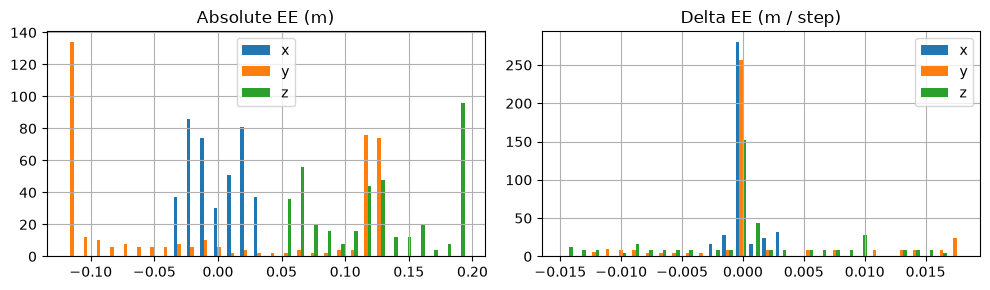

,state_t,absolute_t,delta_t
x,-0.026570,-0.024840,0.00173
y,-0.105420,-0.095040,0.01038
z,0.194635,0.194376,-0.00026


In [14]:
absolute, valid = make_absolute_targets(x, episode_id)
delta, delta_valid = make_delta_targets(x, episode_id)
idx = np.flatnonzero(valid)
assert valid.sum() == len(x) - len(np.unique(episode_id)) == 396
np.testing.assert_array_equal(valid, delta_valid)
np.testing.assert_allclose(x[valid] + delta[valid], x[idx + 1], atol=1e-12)
print(f'{valid.sum()} valid observation-action pairs')
print(f'{(~valid).sum()} invalid observation-action pairs; invalid fraction: {1 - valid.mean():.2%}')
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, targets, title in zip(axes, [absolute, delta], ['Absolute EE (m)', 'Delta EE (m / step)']):
    ax.hist(targets[valid], bins=30, label=['x', 'y', 'z']); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()
display(pd.DataFrame({'state_t': x[i], 'absolute_t': absolute[i], 'delta_t': delta[i]}, index=['x', 'y', 'z']))

**Your task.** Answer two questions:

1. How many observation-action pairs have `valid=False`? Explain why this number is equal to
   the number of episodes.<br>
**Answer:** 4 observation-action pairs have `valid=False`, because at the end of each episode there is a last frame that has no next frame in the current episode making it invalid.

2. Suppose the model must predict a complete chunk of 4 consecutive future actions and we
   discard incomplete chunks. How many starting observations would be invalid? By how much
   would this number increase compared with one-step prediction?<br>
**Answer:** There would be 16 invalid observation, so an increase by 12 compared to one-step prediction.

## E. Temporal alignment ablation
The goal of this section is to detect whether actions are stored on the correct rows relative
to observations. In a correctly aligned dataset, the delta action on row $t$ should transform
$x_t$ into $x_{t+1}$. A one-row shift can still produce smooth, plausible-looking data, but a
behavior-cloning model trained on it will associate each observation with the wrong action.

We compare the original actions with an intentionally corrupted recording
$b_t=a_{t+1}$. For each recording, we try lookup lags from −2 to +2 and ask which lag best
reconstructs the true next state. Our convention is
`state[t] + recorded_action[t + k]`: a positive lag reads an action from a later row.
For the corrupted recording, the correct action $a_t$ is found at $b_{t-1}$, so we expect the
minimum at $k=-1$. Predict both minima before running the cells.

$$E(k)=\frac1N\sum_t\|x_{t+1}-(x_t+a_{t+k})\|_2^2.$$

This is mean **squared Euclidean error per transition**, in m²; do not average over coordinates
again. Use the intersection of valid evaluation rows across **both recordings and all five lags**.
No `np.roll`: it silently wraps episode boundaries.

### E1. Prepare the recordings and a common evaluation set
This cell keeps the original delta actions as the control recording and creates a second
recording shifted by one row, without copying actions across episode boundaries.

It then constructs `common`: transitions for which every tested lag is valid in both
recordings and remains inside the same episode. Using exactly the same rows for every comparison
makes differences in reconstruction error attributable to alignment rather than to a changing
evaluation sample.

In [15]:
lags = np.arange(-2, 3)
broken = np.zeros_like(delta)
broken_valid = np.zeros(len(x), dtype=bool)
rows = np.arange(len(x) - 1)
ok = valid[rows] & valid[rows + 1] & (episode_id[rows] == episode_id[rows + 1])
broken_valid[rows[ok]] = True
broken[rows[ok]] = delta[rows[ok] + 1]
recordings = {'original': (delta, valid), 'shifted_plus_one': (broken, broken_valid)}
common_mask = valid.copy()
rows = np.arange(len(x))
for actions, action_valid in recordings.values():
    for k in lags:
        source = rows + k
        in_bounds = (source >= 0) & (source < len(x))
        safe = np.clip(source, 0, len(x) - 1)
        common_mask &= in_bounds & action_valid[safe] & (episode_id[safe] == episode_id)
common = np.flatnonzero(common_mask)
assert len(common) == 376
print('Same evaluation transitions for every comparison:', len(common))

Same evaluation transitions for every comparison: 376


### E2. Implement the reconstruction error

Reconstruct `x[t+1]` from `x[t]` and the action found at `t + lag`. Return the mean squared Euclidean error on the supplied `rows`. Keep the state rows fixed and do not choose a different row set for each lag.

<details><summary>Hint 1</summary>

Look up actions at rows + lag, but keep both state rows fixed.

</details>

<details><summary>Hint 2</summary>

Subtract prediction from x[rows + 1], square, sum over coordinates, then average over transitions.

</details>

In [ ]:
def reconstruction_error(x, actions, rows, lag):
    # TO DO: reconstruct next state and average squared vector errors.
    pred = x[rows] + actions[rows + lag] 
    err  = x[rows + 1] - pred 
    return np.mean(np.sum(err ** 2, axis=1)) 

### E3. Scan the candidate lags
The first assertion checks the error definition: an error vector `[1, 2, 2]` has squared
Euclidean error $1^2+2^2+2^2=9$, rather than the coordinate-wise mean 3.

The rest of the cell evaluates every lag for both recordings. The table and left plot show
where each error curve reaches its minimum. The right plot gives a visual example of how the
shifted action signal differs from the original signal. The lag with the smallest error is the
estimated row offset needed to align actions with observations.

recording,original,shifted_plus_one
lag,,
-2,0.000014,0.000004
-1,0.000004,0.000000
0,0.000000,0.000004
1,0.000004,0.000014
2,0.000014,0.000029


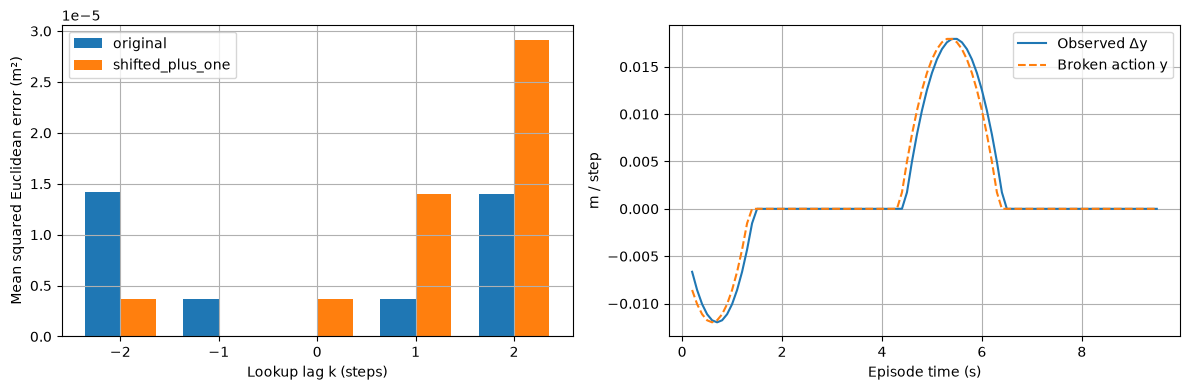

In [17]:
# Distinguishes squared Euclidean error from coordinate-wise MSE.
probe = np.array([[0., 0., 0.], [1., 2., 2.]])
assert np.isclose(reconstruction_error(probe, np.zeros_like(probe), np.array([0]), 0), 9.)
alignment_table = pd.DataFrame([
    {'recording': name, 'lag': int(k), 'error_m2': reconstruction_error(x, actions, common, k), 'n': len(common)}
    for name, (actions, _) in recordings.items() for k in lags])
display(alignment_table.pivot(index='lag', columns='recording', values='error_m2'))
best = alignment_table.loc[alignment_table.groupby('recording').error_m2.idxmin()]
assert best.set_index('recording').lag.to_dict() == {'original': 0, 'shifted_plus_one': -1}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for offset, (name, group) in zip([-0.18, 0.18], alignment_table.groupby('recording')):
    axes[0].bar(group.lag + offset, group.error_m2, width=0.36, label=name)
axes[0].set(xlabel='Lookup lag k (steps)', ylabel='Mean squared Euclidean error (m²)', xticks=lags); axes[0].legend()
plot_rows = common[episode_id[common] == EPISODE]
axes[1].plot(data['timestamp'][plot_rows], delta[plot_rows, 1], label='Observed Δy')
axes[1].plot(data['timestamp'][plot_rows], broken[plot_rows, 1], '--', label='Broken action y')
axes[1].set(xlabel='Episode time (s)', ylabel='m / step'); axes[1].legend()
plt.tight_layout(); plt.show()

**Your task.** Answer four questions:

1. What is the best lag for the original recording? What does this result say about its
   alignment?<br>
Best lag is 0. This says the original recording is correctly aligned.

2. What is the best lag for the shifted recording? What row shift does this result identify?<br>
Best lag = −1. This identifies a +1 row shift in the recording.

3. What is the reconstruction error of the shifted recording at `lag = 0`?<br>
0.000004 

4. Why must every lag be evaluated on the same rows stored in `common`?<br>
So that error differences reflect alignment only, not a changing evaluation sample. Using common fixes the transition set across every k and both recordings, making the argmin trustworthy.

## F. Absolute vs delta under coordinate translation
Add the same fixed vector `c = [0.10, 0, 0] m` to every Cartesian position.
Keep episodes, rows and motion unchanged. Recompute targets, then report the **vector** mean
change and its norm. Reconstruct the translated trajectory using the translated targets.
This tests representation algebra, not policy generalization. A coordinate-origin movement
has the opposite sign to the coordinate-value offset used here.

### F1. Measure representation sensitivity

Return `(mean_shift_vector, reconstruction_error)` with shapes `(3,)` and scalar. Use only valid rows.

<details><summary>Hint 1</summary>

Use the same target builder before and after adding the offset.

</details>

<details><summary>Hint 2</summary>

Average translated minus original targets over valid rows. Absolute predicts directly; delta adds the translated current state.

</details>

In [ ]:
def translation_metrics(x, episode_id, offset, representation):
    # TO DO: build original/translated targets and reconstruct translated next states.
    x_shifted = x + offset
    if representation == 'absolute':
        targets_orig, valid = make_absolute_targets(x,         episode_id)
        targets_new,  _  = make_absolute_targets(x_shifted, episode_id)
    elif representation == 'delta':
        targets_orig, valid = make_delta_targets(x,         episode_id)
        targets_new,  _  = make_delta_targets(x_shifted, episode_id)
    else:
        raise ValueError(representation)

    mean_shift = (targets_new[valid] - targets_orig[valid]).mean(axis=0) # (3,)

    rows = np.flatnonzero(valid)
    if representation == 'absolute':
        pred = targets_new[valid]
    else:  # delta
        pred = x_shifted[valid] + targets_new[valid]
    error = np.mean(np.sum((x_shifted[rows + 1] - pred) ** 2, axis=1))

    return mean_shift, error

,representation,mean_dx_m,mean_dy_m,mean_dz_m,shift_norm_m,error_m2
0,absolute,0.1,0.0,0.0,0.1,0.0
1,delta,0.0,0.0,0.0,0.0,0.0


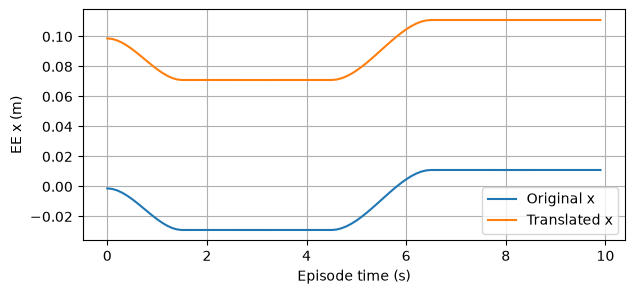

In [19]:
offset = np.array([0.10, 0., 0.])
representation_rows = []
for name in ['absolute', 'delta']:
    shift, error = translation_metrics(x, episode_id, offset, name)
    assert shift.shape == (3,) and np.ndim(error) == 0
    np.testing.assert_allclose(shift, offset if name == 'absolute' else 0, atol=1e-12)
    assert error < 1e-20
    representation_rows.append({'representation': name, 'mean_dx_m': shift[0], 'mean_dy_m': shift[1],
                                'mean_dz_m': shift[2], 'shift_norm_m': np.linalg.norm(shift), 'error_m2': error})
representation_table = pd.DataFrame(representation_rows)
display(representation_table)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(data['timestamp'][ep_idx], x[ep_idx, 0], label='Original x')
ax.plot(data['timestamp'][ep_idx], (x + offset)[ep_idx, 0], label='Translated x')
ax.set(xlabel='Episode time (s)', ylabel='EE x (m)'); ax.legend(); plt.show()

A delta target is converted back to an absolute position by adding it to the current
measured state. During a multi-step rollout, prediction errors can therefore accumulate, and an
incorrect current-state measurement affects the reconstructed target. This experiment tests only
a fixed translation; it does not test rotations, scaling or offsets that change between frames.

**Your task.** Use the two rows of `representation_table` to answer
five questions:

1. What is the mean target-shift vector and its norm for the `absolute` representation?<br>
The mean target-shift [0.10, 0.00, 0.00], its norm: 0.10.

2. What is the mean target-shift vector and its norm for the `delta` representation?<br>
The mean target-shift [0.00, 0.00, 0.00], its norm: 0.00.

3. What reconstruction error does each representation produce after the translation?<br>
Both have 0.0 error.

4. Which representation is unchanged by this fixed coordinate translation?<br>
Delta.

5. Give one limitation of delta targets described above. Does this experiment also test
   rotations, scaling or frame-dependent offsets?<br>
Limitation: A delta target must be combined with the current measured state to recover the next position. In a multi-step rollout, prediction errors therefore accumulate, and any error in the current-state measurement propagates directly into the reconstructed target.<br><br>
Does this experiment also test rotations, scaling or frame-dependent offsets?<br>
No. 